<a href="https://colab.research.google.com/github/iman-g/NLP_hands_on_projects/blob/main/News_topic_modeling/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install --upgrade kneed gensim -q  # -q makes it quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import warnings

import spacy
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans
from kneed import KneeLocator
import gensim
from gensim import corpora, models
from gensim.models import CoherenceModel, LdaModel

warnings.filterwarnings("ignore", category=DeprecationWarning)
nltk.download('stopwords', quiet=True)
plt.style.use('seaborn-v0_8-whitegrid') # Makes plots look professional


nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.6 MB/s eta 0:00:00


In [4]:
!wget -N https://raw.githubusercontent.com/bylinina/TMA_seminars/refs/heads/main/news_sample.csv

df = pd.read_csv('news_sample.csv')

# Drop unnamed columns usually created by index saving
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Drop rows where body is NaN
df = df.dropna(subset=['body'])
print(f"Data Shape: {df.shape}")
df.head(10)

--2026-01-02 11:10:14--  https://raw.githubusercontent.com/bylinina/TMA_seminars/refs/heads/main/news_sample.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16044521 (15M) [text/plain]
Saving to: ‘news_sample.csv’

news_sample.csv     100%[===================>]  15.30M  99.3MB/s    in 0.2s    

Last-modified header missing -- time-stamps turned off.
2026-01-02 11:10:14 (99.3 MB/s) - ‘news_sample.csv’ saved [16044521/16044521]

Data Shape: (1961, 8)


,outlet,title,keywords,description,datetime,authors,category,body
0,Wired,How to Watch Movies in Virtual Reality,"['meta', 'netflix', 'amazon prime', 'oculus', ...",Setting up a VR cinema is simple and proves yo...,2022-01-09 07:00:00,['Reece Rogers'],Gear,With bots and console resellers snatching away...
1,Guardian,Can we create a moral metaverse?,"['The metaverse', 'Virtual reality', 'Online a...","In the increasingly lifelike worlds of VR, hig...",2022-05-14 14:00:04,['Laurie Clarke'],Technology,Psychotherapist Nina Jane Patel had been on F...
2,NYT,"92nd Street Y to Host Ron Howard, Gwyneth Palt...","['Books', 'Ninety-Second Street Y', 'Gwyneth P...",The 2019-20 season also features appearances b...,2019-07-17 17:00:04,Sara Aridi,Arts,The upcoming season at 92nd Street Y will feat...
3,NYT,Steven Spielberg on Storytelling’s Power to Fi...,"['Steven Spielberg', 'Shoah Foundation', 'War ...","The director is reissuing “Schindler’s List,” ...",2018-12-18 20:19:54,Adam Popescu,Arts,"LOS ANGELES — “Pinchas, how old are you?” Stev..."
4,Wired,Mass Transit Is in Jeopardy—and So Are Cities,"['public transportation', 'mass transit', 'cit...",Subways and buses are the lifeblood of dense c...,2020-12-14 07:00:00,['Aarian Marshall'],Business,"In the New York City of February 2020, a misse..."
5,Wired,What Is a Robot?,['robotics'],"Introducing ""HardWIRED: Welcome to the Robotic...",2017-08-24 07:00:00,['Matt Simon'],Science,Editor’s note: This is the first entry in a ne...
6,NYT,Misgivings Spoil Plans of Start-Up,"['Bill Clinton', 'SEC', 'Stocks;Bonds', 'Manha...",An underwriter has pulled out of the initial p...,2007-08-22 04:00:00,Saul Hansell,Technology,"Three years ago, at a news conference at Taver..."
7,Wired,The Best Coffee Subscriptions We’ve Savored,"['shopping', 'buying guides', 'coffee', 'kitch...","These services deliver freshly roasted, delici...",2022-04-23 08:00:00,"['Scott Gilbertson', 'Jaina Grey']",Gear,A cup of coffee in the morning is not just ab...
8,NYT,The Robots Are Coming. Prepare for Trouble.,"['Jobs', 'E Commerce', 'Retail', 'Car Service'...",Artificial intelligence won’t eliminate every ...,2020-01-30 10:00:27,David Deming,Business,Americans are worried that technology will soo...
9,Wired,"Your Favorite Sci-Fi Movies, 2000 and Beyond","['movies', 'sci-fi']",You don’t need to set the time machine very fa...,2009-12-08 20:00:00,['Lewis Wallace'],Culture,<< previous image | next image >> ...


In [8]:
stop_words = stopwords.words('english')
allowed_postags = ['NOUN', 'ADJ', 'VERB', 'ADV', 'PROPN']

def process_text_batch(texts):

    clean_texts = []
    # nlp.pipe is much faster than .apply
    for doc in nlp.pipe(texts, batch_size=50, n_process=1):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.pos_ in allowed_postags
            and not token.is_stop
            and not token.is_punct
            and not token.is_digit
        ]
        clean_texts.append(" ".join(tokens))
    return clean_texts

df['clean_text'] = process_text_batch(df['body'].astype(str))

# Remove any rows that became empty after cleaning
df = df[df['clean_text'].str.len() > 0]

df[['body', 'clean_text']]

,body,clean_text
0,With bots and console resellers snatching away...,bot console reseller snatch people chance dire...
1,Psychotherapist Nina Jane Patel had been on F...,psychotherapist nina jane patel facebook horiz...
2,The upcoming season at 92nd Street Y will feat...,upcoming season 92nd street y feature celebrit...
3,"LOS ANGELES — “Pinchas, how old are you?” Stev...",los angeles pinchas old steven spielberg ask w...
4,"In the New York City of February 2020, a misse...",new york city february miss subway train nuisa...
...,...,...
1995,The Monitor is a weekly column devoted to ever...,monitor weekly column devote happen wired worl...
1996,"Hello, and welcome to another edition of The M...",welcome edition monitor wired entertainment ne...
1997,"From driverless cars to delivery drones, a new...",driverless car delivery drone new generation r...
1998,"WASHINGTON — Executives of Facebook, Twitter a...",washington executive facebook twitter google p...


## Gensim (LDA) Model

In [9]:

# 1. Turn strings back into lists of words
texts = df['clean_text'].apply(lambda x: str(x).split())

# 2. Create the Dictionary
id2word = corpora.Dictionary(texts)


# 3. Create the Corpus (Term Document Frequency)
corpus = [id2word.doc2bow(text) for text in texts]

print(f"Dictionary created with {len(id2word)} unique tokens.")


def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):

    coherence_values = []
    model_list = []

    print("Training models...")
    for num_topics in range(start, limit, step):
        # Build LDA model
        model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=num_topics,
                                           random_state=42,
                                           passes=10,
                                           workers=2)
        model_list.append(model)

        # Calculate Coherence Score using C_v (standard metric)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        score = coherencemodel.get_coherence()
        coherence_values.append(score)

        print(f"Num Topics: {num_topics}  |  Coherence Score: {score:.4f}")

    return model_list, coherence_values

start, limit, step = 2, 21, 3
model_list, coherence_values = compute_coherence_values(dictionary=id2word, corpus=corpus, texts=texts, start=start, limit=limit, step=step)

Dictionary created with 49718 unique tokens.
Training models...
Num Topics: 2  |  Coherence Score: 0.2912
Num Topics: 5  |  Coherence Score: 0.3256
Num Topics: 8  |  Coherence Score: 0.3292
Num Topics: 11  |  Coherence Score: 0.3457
Num Topics: 14  |  Coherence Score: 0.3269
Num Topics: 17  |  Coherence Score: 0.3472
Num Topics: 20  |  Coherence Score: 0.3492


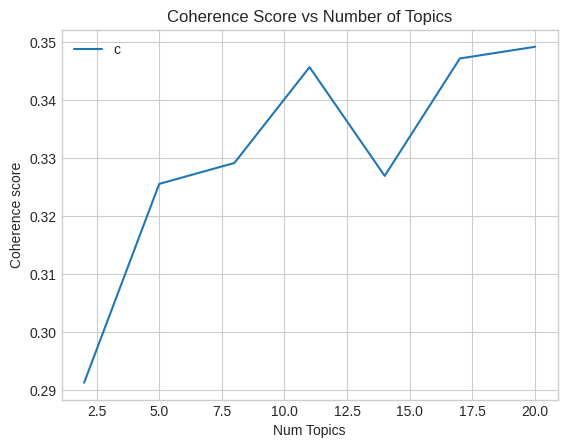

In [10]:
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.title("Coherence Score vs Number of Topics")
plt.show()

## K-Means Model

Matrix Shape: (1961, 25389)
13


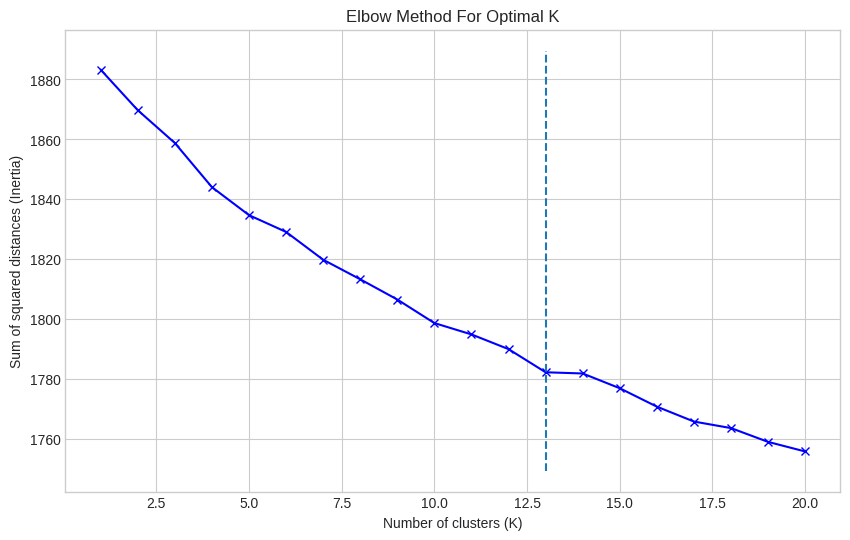

In [11]:

tfidf_vectorizer = TfidfVectorizer(max_df=0.6, min_df=2)

# Fit and transform the 'clean_text' column

tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

# Convert the matrix to a DataFrame for better readability

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out())

print(f"Matrix Shape: {tfidf_df.shape}")



# 1. Calculate "Inertia" for a range of K values (e.g., 1 to 21)
sum_of_squared_distances = []
K_range = range(1, 21)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    sum_of_squared_distances.append(km.inertia_)

kn = KneeLocator(K_range, sum_of_squared_distances, curve='convex', direction='decreasing')
print(kn.knee)


plt.figure(figsize=(10, 6))
plt.plot(K_range, sum_of_squared_distances, 'bx-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of squared distances (Inertia)')
plt.title('Elbow Method For Optimal K')
plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed')
plt.show()



In [12]:

optimal_k = kn.knee

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_final.fit(tfidf_matrix)

df['cluster'] = km_final.labels_
print(df[['outlet', 'title', 'cluster']].head())

     outlet                                              title  cluster
0     Wired             How to Watch Movies in Virtual Reality        1
1  Guardian                   Can we create a moral metaverse?        5
2       NYT  92nd Street Y to Host Ron Howard, Gwyneth Palt...        1
3       NYT  Steven Spielberg on Storytelling’s Power to Fi...        1
4     Wired      Mass Transit Is in Jeopardy—and So Are Cities       11


In [13]:
# Get feature names
terms = tfidf_vectorizer.get_feature_names_out()

# Sort cluster centers by weight (descending)
order_centroids = km_final.cluster_centers_.argsort()[:, ::-1]

# Print top 10 words for each cluster
for i in range(optimal_k):
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_words)}")

Cluster 0: human, computer, scientist, researcher, machine, brain, system, science, datum, technology
Cluster 1: film, movie, art, video, artist, mr, star, book, woman, feel
Cluster 2: apple, device, phone, app, amazon, iphone, wired, best, feature, subscription
Cluster 3: ai, human, technology, machine, intelligence, algorithm, company, artificial, system, datum
Cluster 4: google, company, assistant, search, apple, ad, app, amazon, datum, ai
Cluster 5: facebook, zuckerberg, company, user, platform, content, post, social, medium, ad
Cluster 6: game, player, play, character, alphago, gaming, bee, console, video, match
Cluster 7: security, hacker, attack, ransomware, hack, company, account, malware, bitcoin, user
Cluster 8: robot, human, weapon, robotic, machine, autonomous, job, technology, ai, computer
Cluster 9: mr, china, trump, company, nyt, chinese, president, government, trade, american
Cluster 10: car, vehicle, drive, driver, company, self, autonomous, electric, uber, battery
Clu

In [14]:
print(df['cluster'].value_counts().sort_index())

cluster
0     381
1     406
2     127
3     102
4      82
5      86
6     112
7      99
8      69
9     134
10     67
11    272
12     24
Name: count, dtype: int64
